In [1]:
from torch_harmonics.spherical_harmonics_old import SphericalHarmonics

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from torch_harmonics import plotting
import xarray
import torch
from torch import nn

In [3]:
f = xarray.load_dataset('/home/colin/hdd/workspace/object2sphere/datasets/test_dataset.nc')

In [4]:
f['rti'].shape
# Aspect is at 180 (61)

(3000, 61, 21, 107, 2)

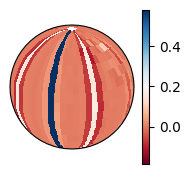

In [21]:
sample = f['rti'][0,:,:,50,0].to_numpy()
y = torch.tensor(sample.transpose(1,0)).view(1,21,61)
plotting.plot_spherical_fn(y.squeeze().numpy(), fig=plt.figure(figsize=(2,2)))

In [8]:
class SHT(nn.Module):
    def __init__(self, L=3, num_theta=21, num_phi=61):
        super().__init__()
        self.L = L
        self.w_lin = nn.Linear(num_theta*num_phi, (L+1)**2)
        self.sh = SphericalHarmonics(L, L, num_lat=num_theta, num_lon=num_phi)
        #self.mlp_out = nn.Linear(num_range*num_theta*num_phi, num_range*num_theta*num_phi)

    def forward(self, x):
        B = x.size(0)
        
        w = self.w_lin(x)
        
        y = self.sh(w).float()#.view(B, self.num_range)
        #y = self.mlp_out(y).view(B,self.sh.num_lat, self.sh.num_lon)
        return y.view(B, self.sh.num_lat, self.sh.num_lon), w.detach()

In [24]:
L = 30
sh_model = SHT(L).cuda()
optimizer = torch.optim.Adam(sh_model.parameters(), lr = 1e-4)

for iter in range(200):
    y_pred, _ = sh_model(y.reshape(1,-1).cuda())
    loss = (y_pred - y.cuda()).pow(2).mean()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if iter % 10 == 0:
        print(f'iteration: {iter} loss: {loss.item()}')

iteration: 0 loss: 0.2780289649963379
iteration: 10 loss: 0.056515224277973175
iteration: 20 loss: 0.019114330410957336
iteration: 30 loss: 0.01040389109402895
iteration: 40 loss: 0.006621775217354298
iteration: 50 loss: 0.0051931957714259624
iteration: 60 loss: 0.004755988717079163
iteration: 70 loss: 0.004544425755739212
iteration: 80 loss: 0.004477258771657944
iteration: 90 loss: 0.004440646152943373
iteration: 100 loss: 0.004420355428010225
iteration: 110 loss: 0.004407139029353857
iteration: 120 loss: 0.004397627431899309
iteration: 130 loss: 0.004390096757560968
iteration: 140 loss: 0.004383739084005356
iteration: 150 loss: 0.004378237761557102
iteration: 160 loss: 0.004373397212475538
iteration: 170 loss: 0.004369078204035759
iteration: 180 loss: 0.0043651871383190155
iteration: 190 loss: 0.004361660685390234


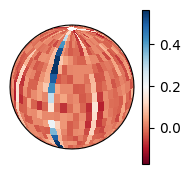

In [25]:
plotting.plot_spherical_fn(y_pred.detach().cpu().squeeze().numpy(), fig=plt.figure(figsize=(2,2)))

In [ ]:
torch.sum(torch.abs(w) < 0.05)

In [ ]:
torch.mean(torch.abs(w))

In [ ]:
import matplotlib.animation as animation

fig = plt.figure(layout='constrained', figsize=(12, 8), dpi=72)

moviewriter = animation.writers['pillow'](fps=30)
moviewriter.setup(fig, 'pred_radar_2__l=100.gif', dpi=72)

num_frames = 360
for frame in range(num_frames):
    # compute the rotation of the sphere
    lon = -num_frames - (360 / num_frames) * frame

    if frame % 10 == 0:
        print(f"frame={frame}")
    
        plotting.plot_spherical_fn(pred.squeeze().numpy(), fig=fig, central_longitude=lon)

    plt.draw()
    moviewriter.grab_frame()

moviewriter.finish()

## Ground Truth
![SegmentLocal](radar.gif "segment")

## Prediction
![SegmentLocal](pred_radar.gif "segment")

## Ground Truth
![SegmentLocal](radar_2.gif "segment")

## Prediction
![SegmentLocal](pred_radar_2.gif "segment")